# Excitation energy $^{16}\text{O}$ with event mixing

In [1]:
from spyral.core.constants import AMU_2_MEV, QBRHO_2_P

from spyral_utils.nuclear import NuclearDataMap
from spyral_utils.nuclear.target import GasTarget, load_target, SolidTarget
from spyral_utils.plot import Histogrammer

import polars as pl
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import vector
import lmfit
from itertools import combinations
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import json
import math 
from mpmath import coulombf, coulombg
from scipy.constants import hbar,c,e, epsilon_0, electron_volt,atomic_mass
%matplotlib widget
plt.close()

nuclear_map = NuclearDataMap()
# Ion Chamber entrance and exit window, thickness in ug/cm^2
ic_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# AT-TPC entrance window, thickness in ug/cm^2
attpc_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# Ion Chamber gas material, pressure in Torr
ic_gas_material = GasTarget(compound=[(6,12,1),(9,18,4)], pressure=200.0, nuclear_data=nuclear_map)
ic_gas_thickness = 0.035 #m


In [2]:
nuclear_map = NuclearDataMap()

# Set some parameters
# workspace_path_target = Path("/Volumes/research_EXT_2/spyral_target_alpha_width3")
# workspace_path_decay = Path("/Volumes/research_EXT_2/spyral_decay_alpha_width3")

# solver_result_path_target = workspace_path_target / "InterpSolver"
# solver_result_path_decay = workspace_path_decay / "InterpSolver"
solver_result_path = Path("/Volumes/researchEXT/O16/all_analysis_spyralv1.0/all_five_tracks_analysis/14082026_all_5tracks") / "InterpSolver"
# Your AT-TPC target gas material
target_material_path = Path("/Users/pranjalsingh/Desktop/research_space_spyral/e20020_analysis/solver_gas_16O.json")

# Run number range (inclusive)
run_min = 54
run_max = 170
# Specify your nuclei

# The nucleus we observe (the one we fitted)
ejectile_z = 2
ejectile_a = 4

# The incoming nucleus (the beam)
projectile_z = 8
projectile_a = 16


channel_z = 8
channel_a = 16 

channel2_z = 4
channel2_a = 8

channel3_z = 6
channel3_a = 12

fusion_z = 10
fusion_a = 20

# The target nucleus
target_z = 2
target_a = 4

# We calculate the residual for you
residual_z = target_z + projectile_z - ejectile_z
residual_a = target_a + projectile_a - ejectile_a


if residual_z < 0:
    raise Exception(f"Illegal nuclei! Residual Z: {residual_z}")  # noqa: TRY002
if residual_a < 1:
    raise Exception(f"Illegal nuclei! Residual A: {residual_a}")  # noqa: TRY002


In [3]:
target_material = load_target(target_material_path, nuclear_map)
if not isinstance(target_material, GasTarget):
    print('Target error!')

ejectile = nuclear_map.get_data(ejectile_z, ejectile_a)
projectile = nuclear_map.get_data(projectile_z, projectile_a)

channel_12c = nuclear_map.get_data(channel3_z, channel3_a)

fusion = nuclear_map.get_data(fusion_z, fusion_a)
target = nuclear_map.get_data(target_z, target_a)
residual = nuclear_map.get_data(residual_z, residual_a)
print(f"Reaction: {target}({projectile}, {ejectile}){residual}")
print(f"Target material: {target_material.ugly_string}")

# Initial beam energy
mass_amu = projectile.mass / AMU_2_MEV # If needed, to convert beam energy in MeV/u -> MeV
proj_energy_accel = 161.0 # MeV, the beam energy from the accelerator

# The beam energy after the ic entrance window
proj_energy_ic = proj_energy_accel #- ic_window_material.get_energy_loss(projectile, proj_energy_accel, np.array([0.0]))[0]
# The beam energy after the ic gas
proj_energy_ic_exit = proj_energy_ic #- ic_gas_material.get_energy_loss(projectile, proj_energy_ic, np.array([ic_gas_thickness]))[0]
# The beam energy after the ic exit window
proj_energy_post_ic = proj_energy_ic_exit #- ic_window_material.get_energy_loss(projectile, proj_energy_ic_exit, np.array([0.0]))[0]
# The beam energy after the AT-TPC entrace window
proj_energy_start = proj_energy_post_ic #- attpc_window_material.get_energy_loss(projectile, proj_energy_post_ic, np.array([0.0]))[0]
# The beam energy at the downstream end of the AT-TPC
proj_energy_stop = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, np.array([1.0]))[0] # Energy at far end of detector
print(f"Accelerator Beam energy: {proj_energy_accel} MeV")
print(f"Beam energy after IC (2 windows + gas): {proj_energy_post_ic} MeV")
print(f"Beam energy range in AT-TPC: {proj_energy_start}-{proj_energy_stop} MeV")


Reaction: 4He(16O, 4He)16O
Target material: (Gas)4He1
Accelerator Beam energy: 161.0 MeV
Beam energy after IC (2 windows + gas): 161.0 MeV
Beam energy range in AT-TPC: 161.0-110.84634259864373 MeV


In [4]:
grammer = Histogrammer()


grammer.add_hist1d('inv_8be_uncorrelated_method2', 60, (0, 20))
grammer.add_hist1d('inv_8be_correlated_method2', 60, (0, 20)) 

grammer.add_hist1d('5_alphas_uncorrelated', 60, (0, 20))
grammer.add_hist1d('5_alphas_correlated', 60, (0, 20))

In [5]:
concat_df = None

for run in range(run_min, run_max+ 1):
    path = solver_result_path / f"run_{run:04d}_4He.parquet"
        
    if not path.exists():
        continue

    df = pl.scan_parquet(path).collect()
    
    if concat_df is not None:
        concat_df = pl.concat([concat_df,df])
    else:
        concat_df = df
        

In [6]:
print(concat_df.shape)

(1721, 20)


In [7]:
def inverse_fermi(energy,c1,c2):
    return np.exp(-c1/c2)*(((1+np.exp(c1/c2))/(1+np.exp(-(energy-c1)/c2)))+1)

In [8]:
def chi_sq_minimize(params,energy,ratio,error):
    c1,c2 = params
    inverse_fermi = np.exp(-c1/c2)*(((1+np.exp(c1/c2))/(1+np.exp(-(energy-c1)/c2)))+1)
    chisq = np.sum(((ratio-inverse_fermi)/error)**2)
    return chisq

## $^{12}\text{C}$ Event Mixing

### Uncorrelated relative energy

In [9]:
grammer.add_hist1d('inv_12c_correlated', 110, (0, 40.0))
grammer.add_hist1d('inv_12c_uncorrelated', 110, (0, 40.0))

In [10]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

counter_inv = 0
inv_energy_arr = []

c12_hoyle_energy = []
counter = 0


df = concat_df.slice(offset=0,length=400) #limited the amount of original events -> less computation

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 


wide = df.pivot(
    on="cluster_index_corr",
    index="event",
    values=["px", "py", "pz", "E"],
) #collaspsing the 5 different entries from 5 alphas into just the four momentum vector on one entry with different alphas 

# print(wide.shape)
# wide.head()

combo_frames = []
for combo_id, (i, j, k) in enumerate(combinations(range(5), 3)): #creates a list of 10 tables, one with each combination
    combo_frames.append(
        wide.select(
            pl.col("event"),
            pl.lit(combo_id).alias("combo_id"),
            (pl.col(f"px_{i}") + pl.col(f"px_{j}") + pl.col(f"px_{k}")).alias("px_tot3"),
            (pl.col(f"py_{i}") + pl.col(f"py_{j}") + pl.col(f"py_{k}")).alias("py_tot3"),
            (pl.col(f"pz_{i}") + pl.col(f"pz_{j}") + pl.col(f"pz_{k}")).alias("pz_tot3"),
            (pl.col(f"E_{i}")  + pl.col(f"E_{j}")  + pl.col(f"E_{k}")).alias("E_tot3"),
        )
    )

three_sums = pl.concat(combo_frames)

alphas_flat = df.select(["event", "px", "py", "pz", "E"]).rename(
    {"event": "event_mix", "px": "px4th", "py": "py4th", "pz": "pz4th", "E": "E4th"}
)

mixed = (
    three_sums.lazy()
    .join(alphas_flat.lazy(), how="cross")
    .filter(pl.col("event") != pl.col("event_mix")) #making sure to not include the 4th alphas as the one from the same event 
    .with_columns(
        (pl.col("px_tot3") + pl.col("px4th")).alias("Px"), #adding the four momentum vector for the 4th alpha and assigning to a total energy
        (pl.col("py_tot3") + pl.col("py4th")).alias("Py"),
        (pl.col("pz_tot3") + pl.col("pz4th")).alias("Pz"),
        (pl.col("E_tot3")  + pl.col("E4th")).alias("Etot"),
    )
    .with_columns(
        pl.max_horizontal(
            pl.col("Etot")**2 - (pl.col("Px")**2 + pl.col("Py")**2 + pl.col("Pz")**2),  #getting the inariant mass
            pl.lit(0.0),
        ).sqrt().alias("inv_mass")
    )
    .with_columns(
        (pl.col("inv_mass") - (channel_12c.mass + ejectile.mass)).alias("rel_energy") #getting the relativ energy 
    )
    .collect(engine="streaming")
)


uncorr_total_counts = mixed.height

relative_uncorr = mixed["rel_energy"].to_list()
grammer.fill_hist1d("inv_12c_uncorrelated",relative_uncorr)


True

### Correlated Relative Energy

In [11]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

df = concat_df

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 


wide = df.pivot(
    on="cluster_index_corr",
    index="event",
    values=["px", "py", "pz", "E"],
) #collaspsing the 5 different entries from 5 alphas into just the four momentum vector on one entry with different alphas 

# print(wide.shape)
# wide.head()

combo_frames = []
for combo_id, (i, j, k, m) in enumerate(combinations(range(5), 4)): #creates a list of 10 tables, one with each combination
    combo_frames.append(
        wide.select(
            pl.col("event"),
            pl.lit(combo_id).alias("combo_id"),
            (pl.col(f"px_{i}") + pl.col(f"px_{j}") + pl.col(f"px_{k}") + pl.col(f"px_{m}")).alias("Px"),
            (pl.col(f"py_{i}") + pl.col(f"py_{j}") + pl.col(f"py_{k}") + pl.col(f"py_{m}")).alias("Py"),
            (pl.col(f"pz_{i}") + pl.col(f"pz_{j}") + pl.col(f"pz_{k}") + pl.col(f"pz_{m}")).alias("Pz"),
            (pl.col(f"E_{i}")  + pl.col(f"E_{j}")  + pl.col(f"E_{k}") + pl.col(f"E_{m}")).alias("Etot"),
        )
    )

four_sums = pl.concat(combo_frames)



mixed = (
    four_sums.lazy()
    .with_columns(
        pl.max_horizontal(
            pl.col("Etot")**2 - (pl.col("Px")**2 + pl.col("Py")**2 + pl.col("Pz")**2),  #getting the inariant mass
            pl.lit(0.0),
        ).sqrt().alias("inv_mass")
    )
    .with_columns(
        (pl.col("inv_mass") - (channel_12c.mass + ejectile.mass)).alias("rel_energy") #getting the relativ energy 
    )
    .collect(engine="streaming")
)

corr_total_counts = mixed.height

relative_corr = mixed["rel_energy"].to_list()
grammer.fill_hist1d("inv_12c_correlated",relative_corr)


True

In [12]:
ratio_counts = corr_total_counts/uncorr_total_counts
print(f"Ratio unorr/corr counts: {ratio_counts}")

Ratio unorr/corr counts: 0.006543052003410059


Normalization factor = 0.007206687806284232

========== DIAGNOSTICS ==========
Number of bins: 110
Correlated counts:
  min = 0.0
  max = 75.0
Uncorrelated counts:
  min = 0.0
  max = 10407.0
Zero uncorrelated bins: 21

Correlation function:
  NaN: 21
  Inf: 0
  minimum = 0.0
  maximum = 69.38

Uncertainty:
  valid bins: 60
  invalid bins: 50


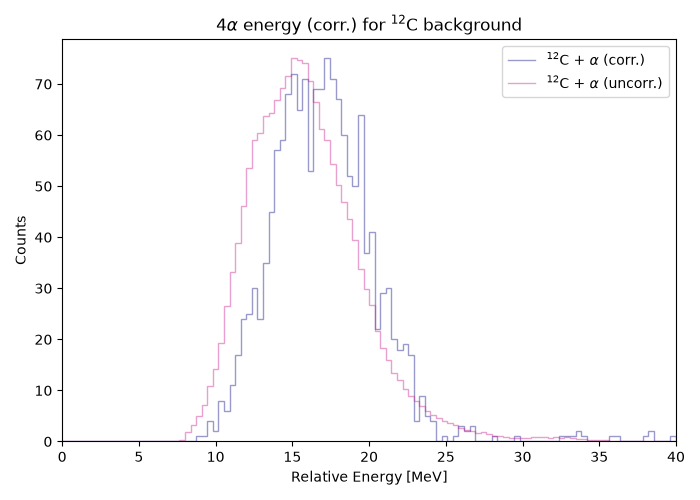

Optimized Parameters (c1, c2): [12.07316174  1.70862639]


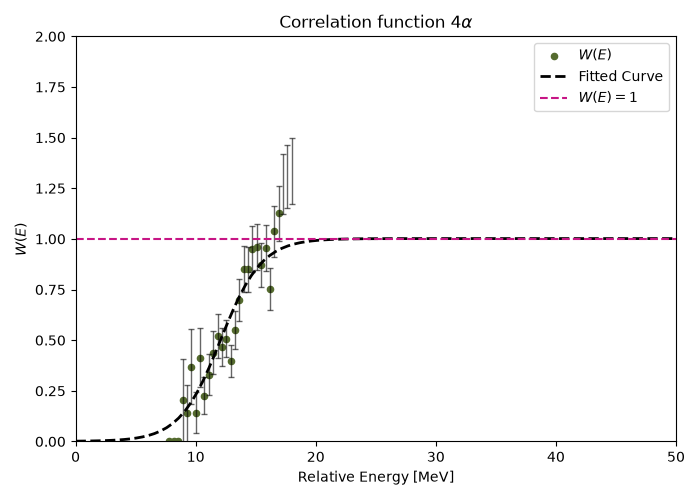

In [13]:
hist_corr = grammer.get_hist1d("inv_12c_correlated")
hist_uncorr_fit = grammer.get_hist1d("inv_12c_uncorrelated")

energy = (hist_corr.bins[:-1] + hist_corr.bins[1:]) / 2

corr = np.asarray(hist_corr.counts, dtype=float)


uncorr = np.asarray(hist_uncorr_fit.counts, dtype=float)

ratio_max = np.max(corr) / np.max(uncorr)

print("Normalization factor =", ratio_max)

uncorr_scaled = uncorr * ratio_max

print("\n========== DIAGNOSTICS ==========")
print("Number of bins:", len(energy))
print("Correlated counts:")
print("  min =", np.min(corr))
print("  max =", np.max(corr))
print("Uncorrelated counts:")
print("  min =", np.min(uncorr))
print("  max =", np.max(uncorr))
print("Zero uncorrelated bins:", np.sum(uncorr == 0))

# subtracted = corr - uncorr_scaled

W = np.divide(
    corr,
    uncorr_scaled,
    out=np.full_like(corr, np.nan),
    where=uncorr_scaled > 0
)

print("\nCorrelation function:")
print("  NaN:", np.sum(np.isnan(W)))
print("  Inf:", np.sum(np.isinf(W)))

finite_W = W[np.isfinite(W)]


# print(finite_W)

if len(finite_W) > 0:
    print("  minimum =", np.min(finite_W))
    print("  maximum =", np.max(finite_W))

error_mask = (
    (corr>0)&
    (uncorr > 0) &
    np.isfinite(W)
)

W_error = np.full_like(W, np.nan)

W_error[error_mask] = (
    W[error_mask]
    * np.sqrt(
        1.0 / corr[error_mask]
        + 1.0 / uncorr[error_mask]
    )
)

# W_error[error_mask] = [1 if math.isnan(x) else x for x in W_error[error_mask]]

# print(W_error[error_mask])

print("\nUncertainty:")
print("  valid bins:", np.sum(error_mask))
print("  invalid bins:", np.sum(~error_mask))

fig, ax = plt.subplots(figsize=(7, 5))

ax.stairs(
    corr,
    edges=hist_corr.bins,
    color="navy",
    alpha=0.4,
    label=r"$^{12}$C + $\alpha$ (corr.)"
)

ax.stairs(
    uncorr_scaled,
    edges=hist_uncorr_fit.bins,
    color="mediumvioletred",
    alpha=0.4,
    label=r"$^{12}$C + $\alpha$ (uncorr.)"
)

ax.set_xlabel("Relative Energy [MeV]")
ax.set_ylabel("Counts")
ax.set_title(r"$4\alpha$ energy (corr.) for $^{12}$C background")
ax.set_xlim(0, 40)
ax.legend()

plt.tight_layout()
plt.show()


plot_mask = np.isfinite(W)


"""
Fitting the inverse fermi
"""

x_data = [i for i in energy[plot_mask] if i < 17]
y_data = W[plot_mask][:len(x_data)]
y_err = W_error[error_mask][:len(x_data)]

initial_guess = [5, 0.8]

popt, pcov = curve_fit(inverse_fermi, x_data, y_data,sigma=y_err, absolute_sigma=True, p0=initial_guess)
print("Optimized Parameters (c1, c2):", popt)
c12_parameters = popt
x_smooth = np.linspace(0,50,100)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    x_data,
    y_data,
    color="darkolivegreen",
    s=20,
    label=r"$W(E)$"
)

ax.plot(x_smooth, inverse_fermi(x_smooth, *popt), label='Fitted Curve', color='black', lw=2, linestyle="--")

ax.errorbar(
    energy[error_mask][:len(x_data)],
    W[error_mask][:len(x_data)],
    yerr=W_error[error_mask][:len(x_data)],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=2,
    alpha=0.6
)

ax.axhline(
    y=1,
    linestyle="--",
    color="mediumvioletred",
    linewidth=1.5,
    label=r"$W(E)=1$"
)

ax.set_xlabel("Relative Energy [MeV]")
ax.set_ylabel(r"$W(E)$")
ax.set_title(r"Correlation function $4\alpha$")
ax.set_xlim(0,50)
ax.set_ylim(0, 2)
ax.legend()

plt.tight_layout()
plt.show()

## Inverse Fermi coefficients

In [14]:
print(f"12C parameters [c1,c2]: {c12_parameters}")

12C parameters [c1,c2]: [12.07316174  1.70862639]


In [15]:
grammer.add_hist1d('ex_12c_correlated', 100, (0, 40.0))
grammer.add_hist1d('ex_12c_uncorrelated', 100, (0, 40.0))

### $^{12}\text{C}$ Excitation Plot

### Correlated

In [16]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

df = concat_df

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 


wide = df.pivot(
    on="cluster_index_corr",
    index="event",
    values=["px", "py", "pz", "E"],
) #collaspsing the 5 different entries from 5 alphas into just the four momentum vector on one entry with different alphas 

# print(wide.shape)
# wide.head()

combo_frames = []
for combo_id, (i, j, k) in enumerate(combinations(range(5), 3)): #creates a list of 10 tables, one with each combination
    combo_frames.append(
        wide.select(
            pl.col("event"),
            pl.lit(combo_id).alias("combo_id"),
            (pl.col(f"px_{i}") + pl.col(f"px_{j}") + pl.col(f"px_{k}")).alias("Px"),
            (pl.col(f"py_{i}") + pl.col(f"py_{j}") + pl.col(f"py_{k}")).alias("Py"),
            (pl.col(f"pz_{i}") + pl.col(f"pz_{j}") + pl.col(f"pz_{k}")).alias("Pz"),
            (pl.col(f"E_{i}")  + pl.col(f"E_{j}")  + pl.col(f"E_{k}")).alias("Etot"),
        )
    )

four_sums = pl.concat(combo_frames)



mixed = (
    four_sums.lazy()
    .with_columns(
        pl.max_horizontal(
            pl.col("Etot")**2 - (pl.col("Px")**2 + pl.col("Py")**2 + pl.col("Pz")**2),  #getting the inariant mass
            pl.lit(0.0),
        ).sqrt().alias("inv_mass")
    )
    .with_columns(
        (pl.col("inv_mass") - channel_12c.mass).alias("rel_energy") #getting the relative energy 
    )
    .collect(engine="streaming")
)

corr_total_counts = mixed.height

relative_corr = mixed["rel_energy"].to_list()
grammer.fill_hist1d("ex_12c_correlated",relative_corr)


True

In [17]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

df = concat_df

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 

df_one_alpha = (
    df
    .with_columns(
        pl.int_range(
            pl.len()
        )
        .shuffle()
        .over("event")
        .alias("random_order")
    )
    .filter(
        pl.col("random_order") == 0
    )
    .select([
        "event",
        "px",
        "py",
        "pz",
        "E"
    ])
)

n_events = df_one_alpha.height

print(
    "Number of valid events:",
    n_events
)

rng = np.random.default_rng(12345)
N_MIXED_EVENTS = 100_000

permutation = rng.permutation(n_events)

n_permutations = int(
    np.ceil(N_MIXED_EVENTS / n_events)
)

all_indices = []

for _ in range(n_permutations):

    p = rng.permutation(n_events)

    all_indices.append(p)


all_indices = np.concatenate(all_indices)

all_indices = all_indices[
    :N_MIXED_EVENTS + 2
]

event_1 = all_indices[:-4]
event_2 = all_indices[1:-3]
event_3 = all_indices[2:-2]

px = df_one_alpha["px"].to_numpy()
py = df_one_alpha["py"].to_numpy()
pz = df_one_alpha["pz"].to_numpy()
E = df_one_alpha["E"].to_numpy()


px_total = (
    px[event_1]
    + px[event_2]
    + px[event_3]
)

py_total = (
    py[event_1]
    + py[event_2]
    + py[event_3]
)

pz_total = (
    pz[event_1]
    + pz[event_2]
    + pz[event_3]
)

E_total = (
    E[event_1]
    + E[event_2]
    + E[event_3]
)

mass_squared = (
    E_total**2
    - px_total**2
    - py_total**2
    - pz_total**2
)

inv_mass = np.sqrt(
    np.maximum(
        mass_squared,
        0.0
    )
)
rel_energy = (
    inv_mass
    - channel_12c.mass
)

uncorr_total_counts_method2 = len(rel_energy)

print(
    "Number of mixed events:",
    uncorr_total_counts_method2
)

grammer.fill_hist1d(
    "ex_12c_uncorrelated",
    rel_energy.tolist()
)




Number of valid events: 307
Number of mixed events: 99998


True

In [18]:
def background_opt(scale,shift,uncorr_scaled_2,bins):
    # return np.abs(counts_corr - scale*counts_uncorr)
    shifted_bins = bins + shift#1.7143
    bin_centers = (shifted_bins[:-1] + shifted_bins[1:]) / 2
    weight = inverse_fermi(bin_centers,*c12_parameters)
    uncorr_fermi = uncorr_scaled_2*weight
    return scale*uncorr_fermi

In [19]:
def breit_wigner(bin_edges,amplitude,centroid,width):
    lower = bin_edges[:-1]
    upper = bin_edges[1:]
    
    integral = (
        np.arctan(2 * (upper - centroid) / width)
        - np.arctan(2 * (lower - centroid) / width)
    ) / np.pi

    return amplitude * integral

In [20]:
HC = hbar * c / electron_volt / 1e6 * 1e15 # MeV fm
e2 = (e**2/ (4 * np.pi * epsilon_0)/ electron_volt/ 1e6* 1e15)

print(e2)

1.4399645468667814


In [21]:
r0 = 1.4  # fm
A_ALPHA = 4
A_BE8 = 8
R_be8 = r0 * (A_ALPHA**(1/3)+ A_BE8**(1/3))
R_4he = r0 * 2*(A_ALPHA**(1/3))

Z_ALPHA = 2
Z_BE8 = 4

AMU_MEV = (atomic_mass * c**2/ electron_volt / 1e6)

mu_be8 = (A_ALPHA * A_BE8/ (A_ALPHA + A_BE8)) * AMU_MEV
mu_4he = (A_ALPHA * A_ALPHA/ (A_ALPHA + A_ALPHA)) * AMU_MEV

In [22]:
def p_l_coul(l, E, Z1, Z2, mu, R):
    scalar_input = np.ndim(E) == 0
    E = np.atleast_1d(np.asarray(E, dtype=float))

    E_safe = np.maximum(E, 1e-10)

    k = np.sqrt(2 * mu * E_safe) / HC

    eta = (
        Z1 * Z2 * e2 * mu
        / (HC**2 * k)
    )

    rho = k * R

    F_array = np.empty_like(E)
    G_array = np.empty_like(E)

    for i, (eta_i, rho_i) in enumerate(zip(eta, rho)):

        F_array[i] = coulombf(
            l,
            eta_i,
            rho_i
        )

        G_array[i] = coulombg(
            l,
            eta_i,
            rho_i
        )

    P = rho / (
        F_array**2
        + G_array**2
    )

    if scalar_input:
        return P[0]

    return P
    

In [23]:
def gamma_coulomb(E,l,centroid,width,Z1,Z2,mu,R):

    P_E = p_l_coul(l,E,Z1,Z2,mu,R)

    P_E0 = p_l_coul(l,centroid,Z1,Z2,mu,R)

    return width * P_E / P_E0

In [24]:
def bw_energy_dependent_coul(E,l,centroid,width,Z1,Z2,mu,R):

    gamma = gamma_coulomb(E,l,centroid,width,Z1,Z2,mu,R)

    return (gamma / 2)**2/((E - centroid)**2+ (gamma / 2)**2)


In [25]:

def breit_wigner_coulomb(bin_edges,amplitude,l,centroid,width,Z1,Z2,mu,R):
    
    energy = (bin_edges[:-1]+ bin_edges[1:]) / 2
    bin_width = (bin_edges[1:]- bin_edges[:-1])

    shape = bw_energy_dependent_coul(energy,l,centroid,width,Z1,Z2,mu,R)

    shape_counts = shape * bin_width

    return amplitude * shape_counts

In [26]:
def total_fit(params, corr, uncorr, bin_edges, l1, l2, Z1,Z2,mu,R ):
    scale,shift,amplitude,centroid,width,amplitude2,centroid2,width2,amplitude3,centroid3,width3,amplitude4,centroid4,width4 = params
    bw_counts = breit_wigner(bin_edges,amplitude,centroid,width)
    bw_counts2 = breit_wigner(bin_edges,amplitude2,centroid2,width2)
    bw_counts3 = breit_wigner(bin_edges,amplitude3,centroid3,width3)
    bw_counts4 = breit_wigner(bin_edges,amplitude4,centroid4,width4)
    # bw_counts3 = breit_wigner(bin_edges,amplitude,centroid,width)
    # bw_counts = breit_wigner_coulomb(bin_edges,amplitude,l1,centroid,width,Z1,Z2,mu,R)
    # bw_counts2 = breit_wigner_coulomb(bin_edges,amplitude2,l2,centroid2,width2,Z1,Z2,mu,R)
    bkg_counts = background_opt(scale,shift,uncorr,bin_edges)
    total_fit = bkg_counts + bw_counts + bw_counts2 #+ bw_counts3 + bw_counts4
    # total_fit = bw_counts + bw_counts2 + bkg_counts
    return np.sum(np.abs(corr - total_fit))
    

In [27]:
hist_corr = grammer.get_hist1d("ex_12c_correlated")
hist_uncorr = grammer.get_hist1d("ex_12c_uncorrelated")

corr = np.asarray(hist_corr.counts, dtype=float)
uncorr = np.asarray(hist_uncorr.counts, dtype=float)

ratio_max = np.max(corr) / np.max(uncorr)

# print("Normalization factor =", ratio_max)

uncorr_scaled_2 = uncorr 

# print("\n========== DIAGNOSTICS ==========")
# print("Number of bins:", len(energy))
# print("Correlated counts:")
# print("  min =", np.min(corr))
# print("  max =", np.max(corr))
# print("Uncorrelated counts:")
# print("  min =", np.min(uncorr))
# print("  max =", np.max(uncorr))
# print("Zero uncorrelated bins:", np.sum(uncorr == 0))


guess = [ratio_max,0.72,100,7.60,0.02,100,10.78,0.5,100,12,0.4,100,13,0.4] #scale,shift,amplitude,centroid,width

bounds = [(0,None),(0,4),(25,200),(7.45,7.8),(0.01,0.2),(50,200),(10.6,11.23),(0.1,0.5),(0,200),(10,12),(0.1,0.8),(0,200),(12.84,13.4),(0.1,0.8)]  #scale,shift,amplitude,centroid,width,amplitude2,centroid2,width2

hist_uncorr_bincenters = (hist_uncorr.bins[:-1] + hist_uncorr.bins[1:]) / 2

result = minimize(
    total_fit,
    guess,
    args=(corr,uncorr, hist_uncorr.bins,0,2,Z_ALPHA,Z_ALPHA,mu_4he,R_4he), #(params, corr, uncorr, bin_edges, l1, l2, Z1,Z2,mu,R )
    method="Powell",
    bounds=bounds,
    options={'maxiter': 500, 'disp': True,'xtol': 1e-8, 'ftol': 1e-8}
)


print(f"Optimization Success: {result.success}")
opt_scale,opt_shift,opt_amplitude,opt_centroid,opt_width,opt_amplitude2,opt_centroid2,opt_width2,opt_amplitude3,opt_centroid3,opt_width3,opt_amplitude4,opt_centroid4,opt_width4 = result.x
print(f"Scaling factor: {opt_scale}")
print(f"Breit Wigner Centroid: {opt_centroid}")

shifted_bins = hist_uncorr.bins + opt_shift#1.7143
bin_centers = (shifted_bins[:-1] + shifted_bins[1:]) / 2
weight = inverse_fermi(bin_centers,*c12_parameters)

uncorr_fermi = uncorr_scaled_2*weight

bw_counts_1 = breit_wigner(hist_uncorr.bins, opt_amplitude,opt_centroid,opt_width)
bw_counts_2 = breit_wigner(hist_uncorr.bins, opt_amplitude2,opt_centroid2,opt_width2)
# bw_counts_3 = breit_wigner(hist_uncorr.bins, opt_amplitude3,opt_centroid3,opt_width3)
# bw_counts_4 = breit_wigner(hist_uncorr.bins, opt_amplitude4,opt_centroid4,opt_width4)

print(opt_amplitude,opt_amplitude2)
# bw_counts_1 = breit_wigner_coulomb(hist_uncorr.bins,opt_amplitude,0,opt_centroid,opt_width,Z_ALPHA,Z_ALPHA,mu_4he,R_4he)
# bw_counts_2 = breit_wigner_coulomb(hist_uncorr.bins,opt_amplitude2,2,opt_centroid2,opt_width2,Z_ALPHA,Z_ALPHA,mu_4he,R_4he)

Optimization terminated successfully.
         Current function value: 321.207517
         Iterations: 3
         Function evaluations: 1877
Optimization Success: True
Scaling factor: 0.04778804008234304
Breit Wigner Centroid: 7.79999999999999
25.00000000621799 50.00000000529039


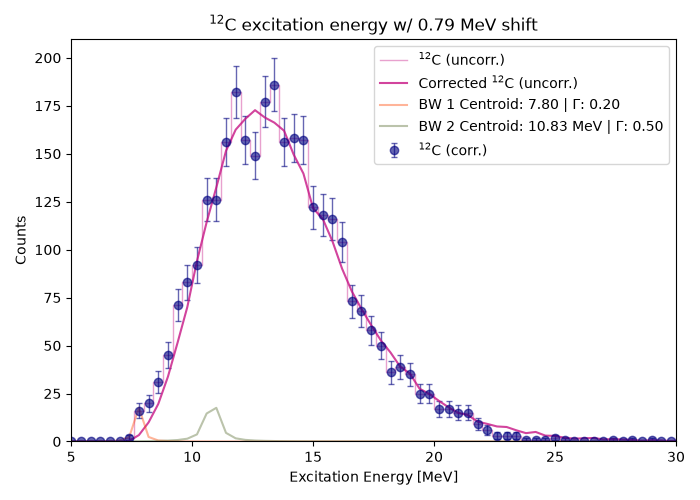

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    hist_uncorr_bincenters,
    corr,
    yerr= np.sqrt(corr),
    color="navy",
    label=r"$^{12}$C (corr.)",
    fmt="o",
    ecolor="navy",
    elinewidth=1,
    capsize=2,
    alpha=0.6
)

ax.stairs(
    corr,
    edges=hist_uncorr.bins,
    color="mediumvioletred",
    alpha=0.4,
    label=r"$^{12}$C (uncorr.)"
)

ax.plot(
    hist_uncorr_bincenters,
    uncorr_fermi*opt_scale,
    color="mediumvioletred",
    alpha=0.8,
    label=r"Corrected $^{12}$C (uncorr.)"
)

ax.plot(
    hist_uncorr_bincenters,
    bw_counts_1,
    color="orangered",
    alpha=0.4,
    label=rf"BW 1 Centroid: {opt_centroid:.2f} | $\Gamma$: {opt_width:.2f}"
)

ax.plot(
    hist_uncorr_bincenters,
    bw_counts_2,
    color="darkolivegreen",
    alpha=0.4,
    label=rf"BW 2 Centroid: {opt_centroid2:.2f} MeV | $\Gamma$: {opt_width2:.2f}"
)

# ax.plot(
#     hist_uncorr_bincenters,
#     bw_counts_3,
#     color="blueviolet",
#     alpha=0.4,
#     label=rf"BW 2 Centroid: {opt_centroid3:.2f} MeV | $\Gamma$: {opt_width3:.2f}"
# )

# ax.plot(
#     hist_uncorr_bincenters,
#     bw_counts_4,
#     color="goldenrod",
#     alpha=0.4,
#     label=rf"BW 2 Centroid: {opt_centroid4:.2f} MeV | $\Gamma$: {opt_width4:.2f}"
# )

# ax.plot(
#     hist_uncorr_bincenters,
#     uncorr_fermi*opt_scale+ bw_counts_1 + bw_counts_2, #+ bw_counts_3 + bw_counts_4,
#     color="black",
#     label="Total fit"
# )


ax.set_xlabel("Excitation Energy [MeV]")
ax.set_ylabel("Counts")
ax.set_title(rf"$^{{12}}$C excitation energy w/ {opt_shift:.2f} MeV shift")
# ax.set_title(rf"$^{{12}}$C excitation energy w/ {opt_shift:.2f} MeV shift ($\alpha + \alpha$ Coulomb)")
# ax.set_title(rf"$^{{16}}$O excitation energy w/ {opt_shift:.2f} MeV Breit-Wigner comparison")
ax.set_xlim(5, 30)
ax.legend()

plt.tight_layout()
plt.show()

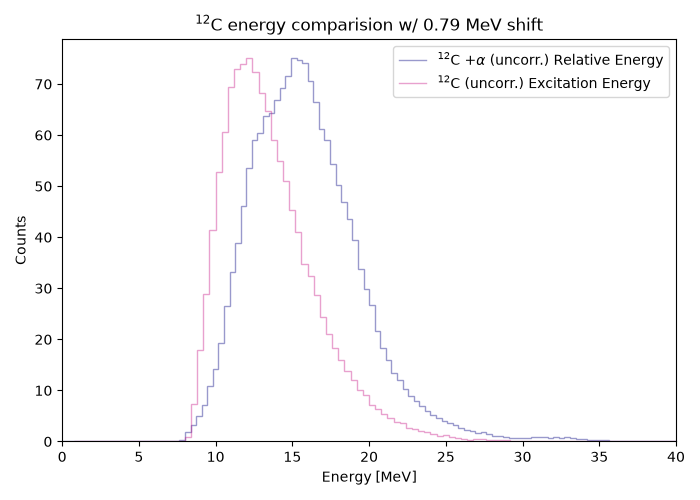

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

ratio_max = np.max(uncorr_scaled) / np.max(uncorr_scaled_2)


ax.stairs(
    uncorr_scaled,
    edges=hist_uncorr_fit.bins  ,
    color="navy",
    alpha=0.4,
    label=r"$^{12}$C $+ \alpha$ (uncorr.) Relative Energy"
)

ax.stairs(
    uncorr_scaled_2*ratio_max,
    edges=hist_uncorr.bins + opt_shift, #1.7143
    color="mediumvioletred",
    alpha=0.4,
    label=r"$^{12}$C (uncorr.) Excitation Energy"
)
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Counts")
ax.set_title(rf"$^{{12}}$C energy comparision w/ {opt_shift:.2f} MeV shift")
ax.set_xlim(0,40)
ax.legend()

plt.tight_layout()
plt.show()